In [109]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Supress Warnings

import warnings
warnings.filterwarnings('ignore')

### Data Integration

In [39]:
#read the datasets
traffic_df = pd.read_excel(r"C:\Users\kriti\Dataset_Uber Traffic.xlsx")
weather_df = pd.read_csv(r"C:\Users\kriti\bangalore_weather_2015_2017.csv")
events_df = pd.read_csv(r"C:\Users\kriti\Bangalore_Event_Data_2015_2017.csv")

In [44]:
# Convert traffic DateTime - using the correct format for your data
traffic_df["DateTime"] = pd.to_datetime(
    traffic_df["DateTime"],
    format="%Y-%m-%d"  # Changed to match "2015-01-01" format (YYYY-MM-DD)
)

# Weather DateTime - using the correct format for your data
weather_df["DateTime"] = pd.to_datetime(
    weather_df["DateTime"], 
    format="%Y-%m-%d"  # Changed to match "2015-01-01" format (YYYY-MM-DD)
)

# Event Date - using the correct format for your data
events_df["Date"] = pd.to_datetime(
    events_df["Date"], 
    format="%Y-%m-%d"  # Changed to match "2015-01-01" format (YYYY-MM-DD)
)

In [45]:
traffic_df["DateTime"] = pd.to_datetime(traffic_df["DateTime"])
weather_df["DateTime"] = pd.to_datetime(weather_df["DateTime"])
events_df["Date"] = pd.to_datetime(events_df["Date"])

In [46]:
traffic_df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [47]:
weather_df.head()

,DateTime,Temperature,Precipitation,Humidity,WindSpeed
0,2015-01-01 00:00:00,19.9,0.2,85,12.3
1,2015-01-01 01:00:00,19.7,0.3,87,9.9
2,2015-01-01 02:00:00,19.5,0.4,88,9.0
3,2015-01-01 03:00:00,19.1,0.5,91,8.5
4,2015-01-01 04:00:00,18.7,0.4,97,8.6


In [48]:
events_df.head()

,Date,Event_Type,Impact_Level
0,2015-01-01,Public Holiday,High
1,2015-01-26,Public Holiday,High
2,2015-03-06,Festival,High
3,2015-04-12,IPL Match,High
4,2015-04-17,IPL Match,High


In [49]:
#merging traffic and weather datasets

df1 = pd.merge(
    traffic_df,
    weather_df,
    on="DateTime",
    how="left"
)
df1.head()

,DateTime,Junction,Vehicles,ID,Temperature,Precipitation,Humidity,WindSpeed
0,2015-11-01 00:00:00,1,15,20151101001,21.1,0.0,89,9.5
1,2015-11-01 01:00:00,1,13,20151101011,21.0,0.0,90,7.8
2,2015-11-01 02:00:00,1,10,20151101021,20.9,0.0,91,6.6
3,2015-11-01 03:00:00,1,7,20151101031,20.8,0.0,92,6.6
4,2015-11-01 04:00:00,1,9,20151101041,20.6,0.0,93,7.0


In [50]:
df1["Date"] = df1["DateTime"].dt.date
df1["Date"] = pd.to_datetime(df1["Date"])

In [51]:
#final merge with event dataset

merged_df = df1.merge(
    events_df,
    on="Date",
    how="left"
)

In [52]:
merged_df.head()

,DateTime,Junction,Vehicles,ID,Temperature,Precipitation,Humidity,WindSpeed,Date,Event_Type,Impact_Level
0,2015-11-01 00:00:00,1,15,20151101001,21.1,0.0,89,9.5,2015-11-01,Public Holiday,High
1,2015-11-01 01:00:00,1,13,20151101011,21.0,0.0,90,7.8,2015-11-01,Public Holiday,High
2,2015-11-01 02:00:00,1,10,20151101021,20.9,0.0,91,6.6,2015-11-01,Public Holiday,High
3,2015-11-01 03:00:00,1,7,20151101031,20.8,0.0,92,6.6,2015-11-01,Public Holiday,High
4,2015-11-01 04:00:00,1,9,20151101041,20.6,0.0,93,7.0,2015-11-01,Public Holiday,High


In [53]:
#creating event flag
merged_df["Event_Flag"] = merged_df["Event_Type"].notnull().astype(int)

### Data Cleaning and pre-processing

In [54]:
merged_df.dtypes

DateTime         datetime64[ns]
Junction                  int64
Vehicles                  int64
ID                        int64
Temperature             float64
Precipitation           float64
Humidity                  int64
WindSpeed               float64
Date             datetime64[ns]
Event_Type               object
Impact_Level             object
Event_Flag                int64
dtype: object

In [55]:
# Dropping helper Date column 
merged_df.drop(columns=["Date"], inplace=True)

In [56]:
#checking null values
merged_df.isnull().sum()

DateTime             0
Junction             0
Vehicles             0
ID                   0
Temperature          0
Precipitation        0
Humidity             0
WindSpeed            0
Event_Type       45792
Impact_Level     45792
Event_Flag           0
dtype: int64

In [57]:
#filling null values
merged_df["Event_Type"] = merged_df["Event_Type"].fillna("No Event")
merged_df["Impact_Level"] = merged_df["Impact_Level"].fillna("None")

In [58]:
merged_df.isnull().sum()

DateTime         0
Junction         0
Vehicles         0
ID               0
Temperature      0
Precipitation    0
Humidity         0
WindSpeed        0
Event_Type       0
Impact_Level     0
Event_Flag       0
dtype: int64

### Feature Engineering

In [59]:
#extracting info from columns
# Hour feature
merged_df["Hour"] = merged_df["DateTime"].dt.hour

# Weekday feature
merged_df["Weekday"] = merged_df["DateTime"].dt.weekday

# Weekend flag
merged_df["Weekend_Flag"] = merged_df["Weekday"].isin([5,6]).astype(int)

# Rain flag
merged_df["Rain_Flag"] = (merged_df["Precipitation"] > 0).astype(int)

In [60]:
merged_df.describe()

,DateTime,Junction,Vehicles,ID,Temperature,Precipitation,Humidity,WindSpeed,Event_Flag,Hour,Weekday,Weekend_Flag,Rain_Flag
count,48120,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000
mean,2016-09-19 06:03:56.109725696,2.180549,22.791334,2.016330e+10,23.544167,0.096687,64.902515,11.272639,0.048379,11.500000,2.996010,0.284289,0.121446
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10,11.500000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10,20.300000,0.000000,46.000000,7.900000,0.000000,5.750000,1.000000,0.000000,0.000000
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10,23.100000,0.000000,68.000000,10.500000,0.000000,11.500000,3.000000,0.000000,0.000000
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10,26.400000,0.000000,85.000000,14.000000,0.000000,17.250000,5.000000,1.000000,0.000000
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10,36.700000,12.100000,100.000000,34.500000,1.000000,23.000000,6.000000,1.000000,1.000000
std,NaN,0.966955,20.750063,5.944854e+06,4.553488,0.502848,22.915280,4.960999,0.214568,6.922258,2.000017,0.451080,0.326649


In [61]:
#saving integrated dataset as csv file
merged_df.to_csv("Traffic_Weather_Event_Final1.csv", index=False)

In [62]:
merged_df.dtypes

DateTime         datetime64[ns]
Junction                  int64
Vehicles                  int64
ID                        int64
Temperature             float64
Precipitation           float64
Humidity                  int64
WindSpeed               float64
Event_Type               object
Impact_Level             object
Event_Flag                int64
Hour                      int32
Weekday                   int32
Weekend_Flag              int64
Rain_Flag                 int64
dtype: object

In [63]:
merged_df.head()

,DateTime,Junction,Vehicles,ID,Temperature,Precipitation,Humidity,WindSpeed,Event_Type,Impact_Level,Event_Flag,Hour,Weekday,Weekend_Flag,Rain_Flag
0,2015-11-01 00:00:00,1,15,20151101001,21.1,0.0,89,9.5,Public Holiday,High,1,0,6,1,0
1,2015-11-01 01:00:00,1,13,20151101011,21.0,0.0,90,7.8,Public Holiday,High,1,1,6,1,0
2,2015-11-01 02:00:00,1,10,20151101021,20.9,0.0,91,6.6,Public Holiday,High,1,2,6,1,0
3,2015-11-01 03:00:00,1,7,20151101031,20.8,0.0,92,6.6,Public Holiday,High,1,3,6,1,0
4,2015-11-01 04:00:00,1,9,20151101041,20.6,0.0,93,7.0,Public Holiday,High,1,4,6,1,0


In [64]:
df = df = merged_df.copy()

In [65]:
df = df.sort_values(by=['Junction', 'DateTime'])

In [66]:
df.head()

,DateTime,Junction,Vehicles,ID,Temperature,Precipitation,Humidity,WindSpeed,Event_Type,Impact_Level,Event_Flag,Hour,Weekday,Weekend_Flag,Rain_Flag
0,2015-11-01 00:00:00,1,15,20151101001,21.1,0.0,89,9.5,Public Holiday,High,1,0,6,1,0
1,2015-11-01 01:00:00,1,13,20151101011,21.0,0.0,90,7.8,Public Holiday,High,1,1,6,1,0
2,2015-11-01 02:00:00,1,10,20151101021,20.9,0.0,91,6.6,Public Holiday,High,1,2,6,1,0
3,2015-11-01 03:00:00,1,7,20151101031,20.8,0.0,92,6.6,Public Holiday,High,1,3,6,1,0
4,2015-11-01 04:00:00,1,9,20151101041,20.6,0.0,93,7.0,Public Holiday,High,1,4,6,1,0


In [67]:
#creating lag features

df['Vehicles_lag1'] = df.groupby('Junction')['Vehicles'].shift(1)   #1-hour lag
df['Vehicles_lag3'] = df.groupby('Junction')['Vehicles'].shift(3)   #3-hour lag
df['Vehicles_lag24'] = df.groupby('Junction')['Vehicles'].shift(24) #24-hour lag

### Data Visualization and Analysis

In [68]:
df.shape

(48120, 18)

In [69]:
df.head()

,DateTime,Junction,Vehicles,ID,Temperature,Precipitation,Humidity,WindSpeed,Event_Type,Impact_Level,Event_Flag,Hour,Weekday,Weekend_Flag,Rain_Flag,Vehicles_lag1,Vehicles_lag3,Vehicles_lag24
0,2015-11-01 00:00:00,1,15,20151101001,21.1,0.0,89,9.5,Public Holiday,High,1,0,6,1,0,NaN,NaN,NaN
1,2015-11-01 01:00:00,1,13,20151101011,21.0,0.0,90,7.8,Public Holiday,High,1,1,6,1,0,15.0,NaN,NaN
2,2015-11-01 02:00:00,1,10,20151101021,20.9,0.0,91,6.6,Public Holiday,High,1,2,6,1,0,13.0,NaN,NaN
3,2015-11-01 03:00:00,1,7,20151101031,20.8,0.0,92,6.6,Public Holiday,High,1,3,6,1,0,10.0,15.0,NaN
4,2015-11-01 04:00:00,1,9,20151101041,20.6,0.0,93,7.0,Public Holiday,High,1,4,6,1,0,7.0,13.0,NaN


In [70]:
df.dtypes

DateTime          datetime64[ns]
Junction                   int64
Vehicles                   int64
ID                         int64
Temperature              float64
Precipitation            float64
Humidity                   int64
WindSpeed                float64
Event_Type                object
Impact_Level              object
Event_Flag                 int64
Hour                       int32
Weekday                    int32
Weekend_Flag               int64
Rain_Flag                  int64
Vehicles_lag1            float64
Vehicles_lag3            float64
Vehicles_lag24           float64
dtype: object

In [71]:
df['DayOfWeek'] = df['DateTime'].dt.day_name()
df['Week'] = df['DateTime'].dt.isocalendar().week
df['Month'] = df['DateTime'].dt.month

In [72]:
#Hourly Congestion (average vehicle count per hour)

hourly_avg = df.groupby('Hour')['Vehicles'].mean().reset_index()
hourly_avg.columns = ['Hour', 'AvgVehicles']

In [73]:
#hour moving average
hourly_avg['MA_3'] = hourly_avg['AvgVehicles'].rolling(window=3, center=True).mean()

In [74]:
hourly_avg[["Hour", "AvgVehicles"]]

,Hour,AvgVehicles
0,0,23.540648
1,1,19.654863
2,2,17.102743
3,3,14.847382
4,4,12.973067
5,5,12.173566
6,6,12.980050
7,7,14.703242
8,8,16.402993
9,9,19.379551


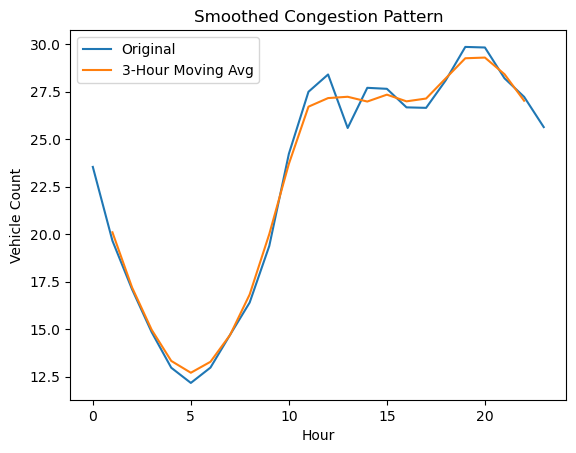

In [75]:
plt.figure()
plt.plot(hourly_avg['Hour'], hourly_avg['AvgVehicles'], label='Original')
plt.plot(hourly_avg['Hour'], hourly_avg['MA_3'], label='3-Hour Moving Avg')
plt.xlabel("Hour")
plt.ylabel("Vehicle Count")
plt.title("Smoothed Congestion Pattern")
plt.legend()
plt.show()

In [76]:
#using standard deviation
mean_val = hourly_avg['AvgVehicles'].mean()
std_val = hourly_avg['AvgVehicles'].std()

hourly_avg['Z_score'] = (hourly_avg['AvgVehicles'] - mean_val) / std_val

In [77]:
peak_hours = hourly_avg[hourly_avg['Z_score'] > 1]
print(peak_hours[['Hour', 'AvgVehicles', 'Z_score']])

    Hour  AvgVehicles   Z_score
19    19    29.854863  1.158595
20    20    29.824938  1.153686


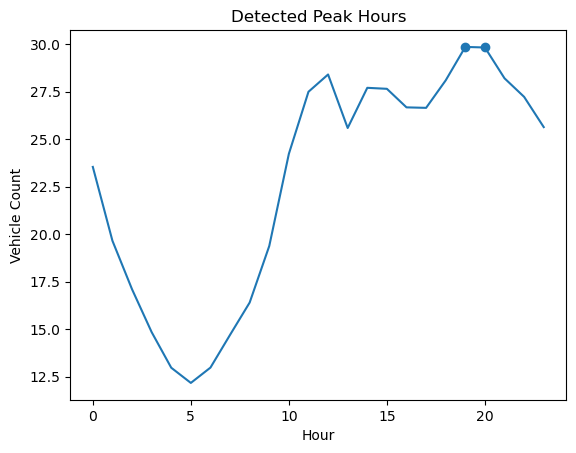

In [78]:
plt.figure()
plt.plot(hourly_avg['Hour'], hourly_avg['AvgVehicles'])
plt.scatter(peak_hours['Hour'],
            peak_hours['AvgVehicles'])

plt.xlabel("Hour")
plt.ylabel("Vehicle Count")
plt.title("Detected Peak Hours")
plt.show()

In [79]:
# peak hours on different days
day_hour = df.groupby(['DayOfWeek','Hour'])['Vehicles'].mean().reset_index()

# compute z-score within each day
day_hour['Z'] = day_hour.groupby('DayOfWeek')['Vehicles']\
                         .transform(lambda x: (x - x.mean())/x.std())

consistent_peaks = day_hour[day_hour['Z'] > 1]

In [80]:
print(consistent_peaks)

     DayOfWeek  Hour   Vehicles         Z
12      Friday    12  30.867596  1.150112
19      Friday    19  30.104530  1.025901
36      Monday    12  33.177700  1.079279
43      Monday    19  32.996516  1.056977
48    Saturday     0  23.332155  1.030026
67    Saturday    19  24.201413  1.217044
68    Saturday    20  27.544170  1.936229
69    Saturday    21  25.579505  1.513537
70    Saturday    22  23.819788  1.134939
91      Sunday    19  22.756098  1.298808
92      Sunday    20  23.860627  1.554008
93      Sunday    21  22.951220  1.343891
94      Sunday    22  22.888502  1.329400
95      Sunday    23  22.195122  1.169195
115   Thursday    19  33.216028  1.157761
139    Tuesday    19  33.048780  1.126062
163  Wednesday    19  32.581882  1.090281
164  Wednesday    20  32.240418  1.040190


In [81]:
order = ['Monday','Tuesday','Wednesday','Thursday',
         'Friday','Saturday','Sunday']

day_hour['DayOfWeek'] = pd.Categorical(
    day_hour['DayOfWeek'],
    categories=order,
    ordered=True
)

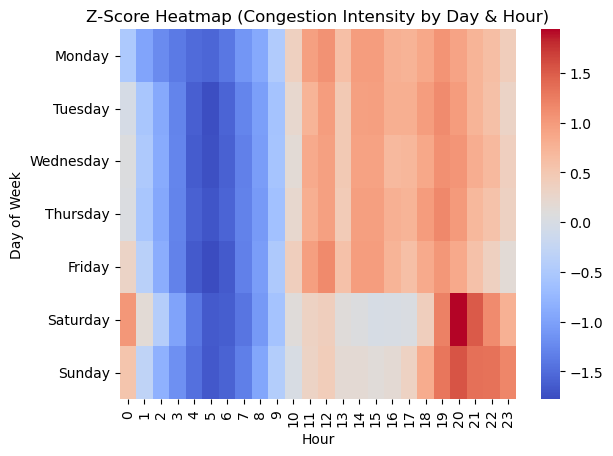

In [82]:
pivot = day_hour.pivot(index='DayOfWeek',
                       columns='Hour',
                       values='Z')

plt.figure()
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Z-Score Heatmap (Congestion Intensity by Day & Hour)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

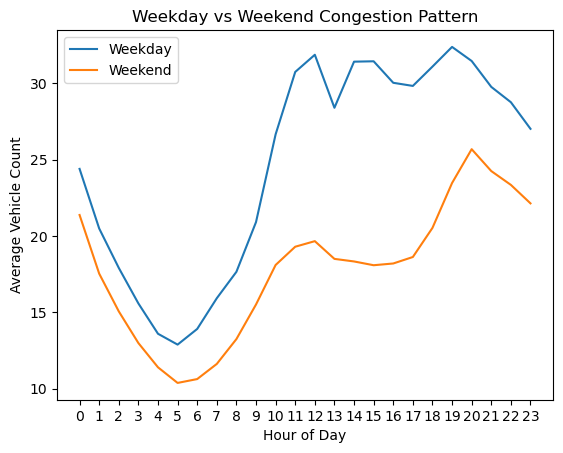

In [83]:
#weekday vs weekend metrics
plt.figure()

weekday_hour = df[df['Weekend_Flag']==0] \
                .groupby('Hour')['Vehicles'].mean()

weekend_hour = df[df['Weekend_Flag']==1] \
                .groupby('Hour')['Vehicles'].mean()

plt.plot(weekday_hour.index, weekday_hour.values, label='Weekday')
plt.plot(weekend_hour.index, weekend_hour.values, label='Weekend')

plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.title("Weekday vs Weekend Congestion Pattern")
plt.xticks(range(0,24))
plt.legend()
plt.show()

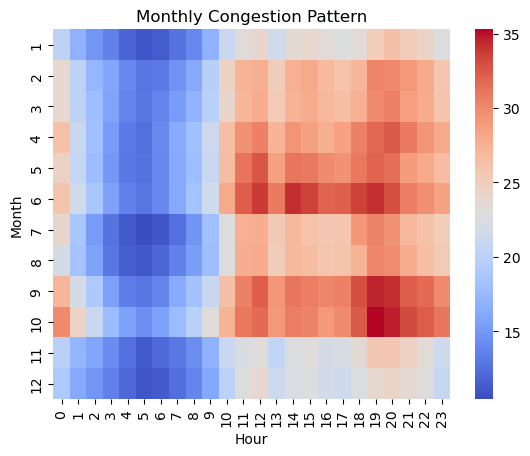

In [84]:
#monthly congestion

monthly_hour = df.groupby(['Month','Hour'])['Vehicles'].mean().reset_index()

pivot_month = monthly_hour.pivot(
    index='Month',
    columns='Hour',
    values='Vehicles'
)

plt.figure()
sns.heatmap(pivot_month, cmap = 'coolwarm')
plt.title("Monthly Congestion Pattern")
plt.xlabel("Hour")
plt.ylabel("Month")
plt.show()

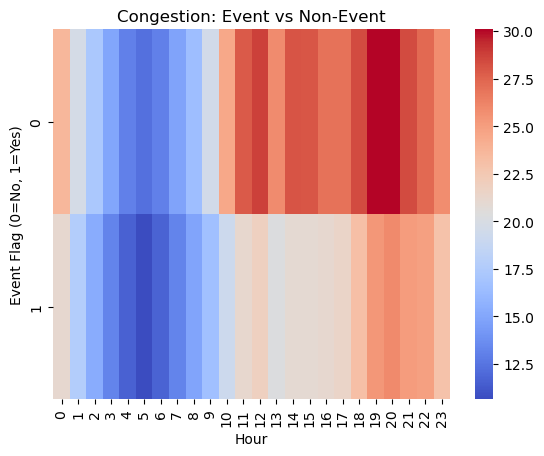

In [85]:
event_hour = df.groupby(['Event_Flag','Hour'])['Vehicles'].mean().reset_index()

pivot_event = event_hour.pivot(
    index='Event_Flag',
    columns='Hour',
    values='Vehicles'
)

plt.figure()
sns.heatmap(pivot_event, cmap = 'coolwarm')
plt.title("Congestion: Event vs Non-Event")
plt.xlabel("Hour")
plt.ylabel("Event Flag (0=No, 1=Yes)")
plt.show()

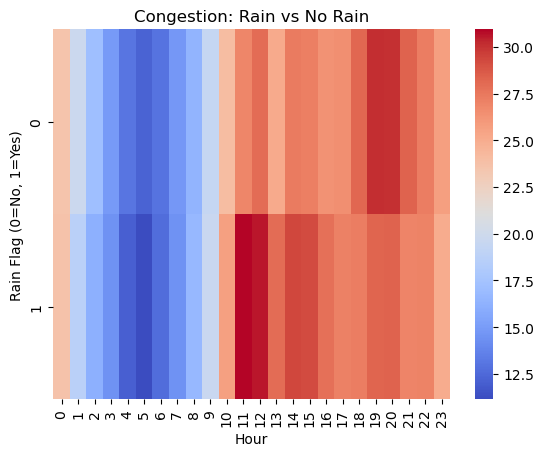

In [86]:
rain_hour = df.groupby(['Rain_Flag','Hour'])['Vehicles'].mean().reset_index()

pivot_rain = rain_hour.pivot(
    index='Rain_Flag',
    columns='Hour',
    values='Vehicles'
)

plt.figure()
sns.heatmap(pivot_rain, cmap = 'coolwarm')
plt.title("Congestion: Rain vs No Rain")
plt.xlabel("Hour")
plt.ylabel("Rain Flag (0=No, 1=Yes)")
plt.show()

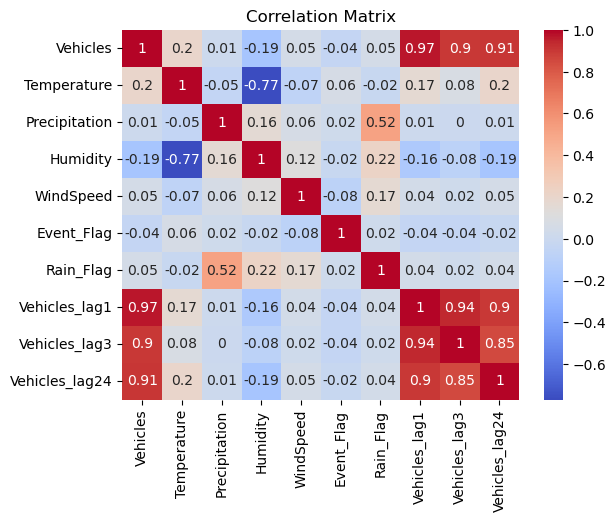

In [87]:
#correlation heatmap
corr_matrix = df[['Vehicles',
                  'Temperature',
                  'Precipitation',
                  'Humidity',
                  'WindSpeed',
                  'Event_Flag',
                  'Rain_Flag',
                  'Vehicles_lag1',
                  'Vehicles_lag3',
                  'Vehicles_lag24']].corr().round(2)


plt.figure()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Other Visualizations

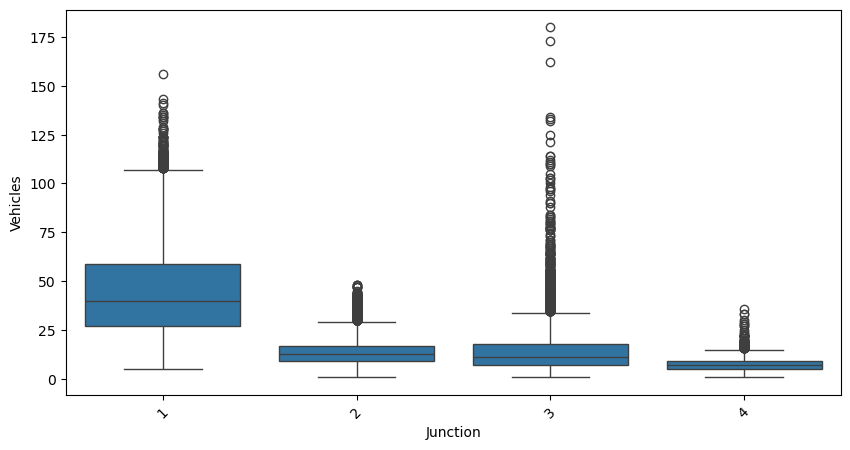

In [88]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Junction', y='Vehicles', data=df)
plt.xticks(rotation=45)
plt.show()

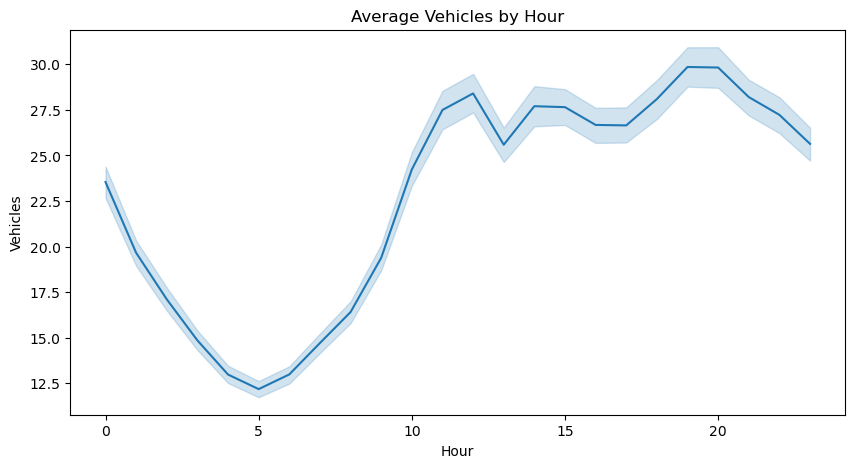

In [91]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Hour', y='Vehicles', data=df, estimator='mean')
plt.title("Average Vehicles by Hour")
plt.show()

In [94]:
#plt.figure(figsize=(15,5))
#sns.lineplot(x='DateTime', y='Vehicles', data=df)
#plt.show()

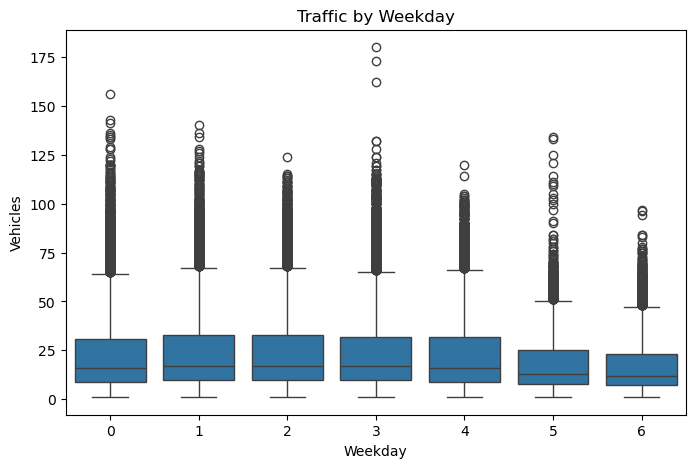

In [93]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Weekday', y='Vehicles', data=df)
plt.title("Traffic by Weekday")
plt.show()

<Axes: xlabel='Weekend_Flag', ylabel='Vehicles'>

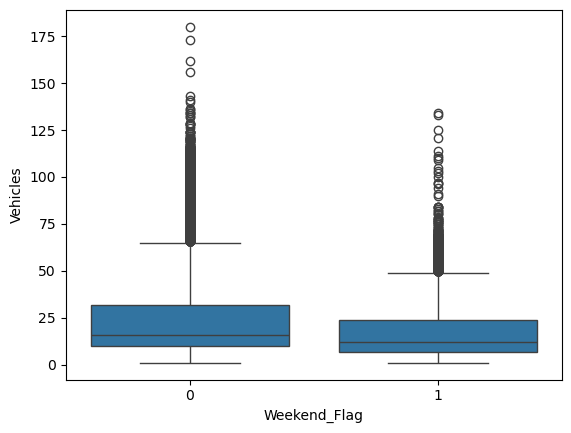

In [95]:
sns.boxplot(x='Weekend_Flag', y='Vehicles', data=df)

<Axes: xlabel='Junction', ylabel='Vehicles'>

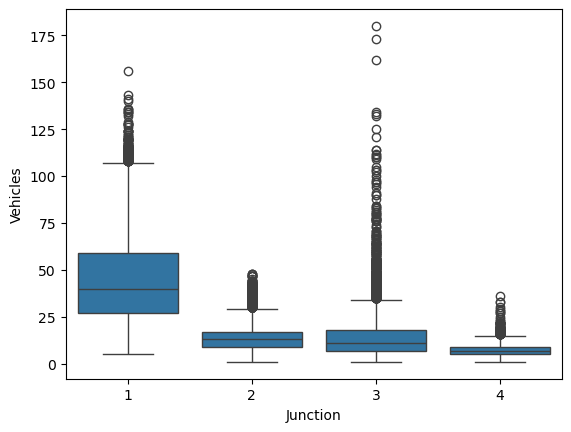

In [96]:
#junction analysis
sns.boxplot(x='Junction', y='Vehicles', data=df)

<Axes: xlabel='Temperature', ylabel='Vehicles'>

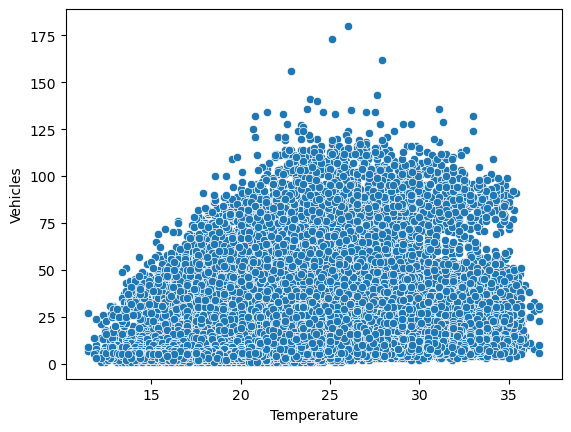

In [97]:
#temperature impact
sns.scatterplot(x='Temperature', y='Vehicles', data=df)

<Axes: xlabel='Rain_Flag', ylabel='Vehicles'>

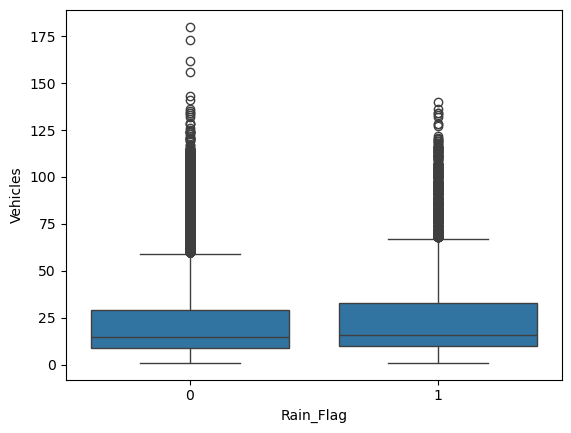

In [98]:
#rain vs no-rain
sns.boxplot(x='Rain_Flag', y='Vehicles', data=df)

<Axes: xlabel='Precipitation', ylabel='Vehicles'>

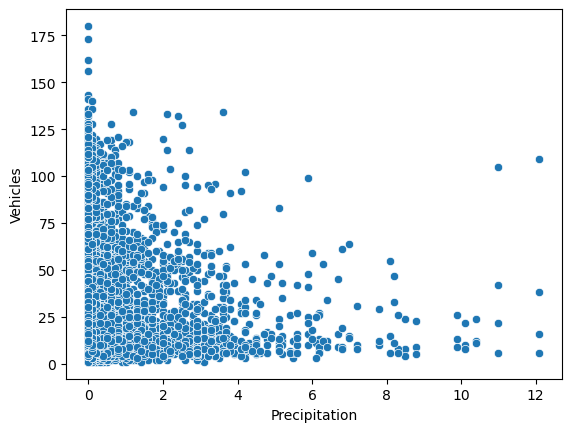

In [99]:
# precipitation impact
sns.scatterplot(x='Precipitation', y='Vehicles', data=df)

<Axes: xlabel='Event_Flag', ylabel='Vehicles'>

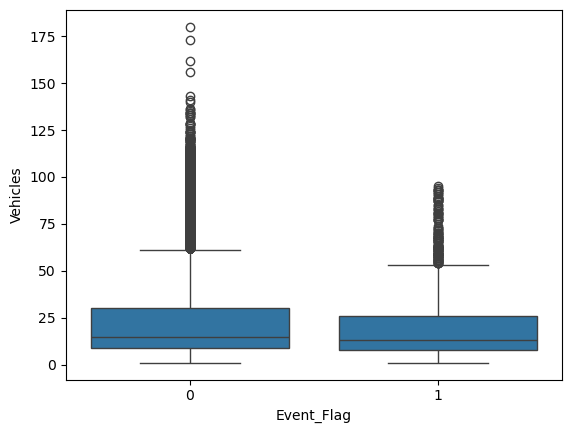

In [100]:
#event ipmact
sns.boxplot(x='Event_Flag', y='Vehicles', data=df)

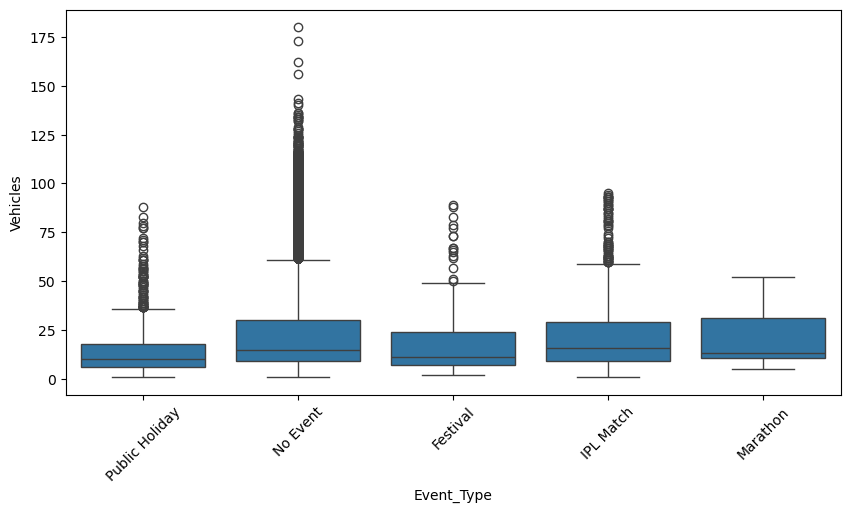

In [101]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Event_Type', y='Vehicles', data=df)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Vehicles_lag1', ylabel='Vehicles'>

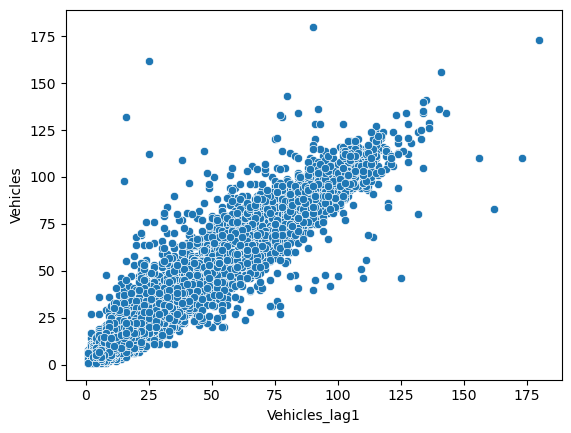

In [102]:
df_lag = df.dropna(subset=['Vehicles_lag1'])
sns.scatterplot(x='Vehicles_lag1', y='Vehicles', data=df_lag)

### Data Modelling and Evaluation

In [103]:
df.isna().sum()

DateTime           0
Junction           0
Vehicles           0
ID                 0
Temperature        0
Precipitation      0
Humidity           0
WindSpeed          0
Event_Type         0
Impact_Level       0
Event_Flag         0
Hour               0
Weekday            0
Weekend_Flag       0
Rain_Flag          0
Vehicles_lag1      4
Vehicles_lag3     12
Vehicles_lag24    96
DayOfWeek          0
Week               0
Month              0
dtype: int64

In [104]:
#removing null values
df_model = df.dropna()

In [105]:
df_model.isnull().sum()

DateTime          0
Junction          0
Vehicles          0
ID                0
Temperature       0
Precipitation     0
Humidity          0
WindSpeed         0
Event_Type        0
Impact_Level      0
Event_Flag        0
Hour              0
Weekday           0
Weekend_Flag      0
Rain_Flag         0
Vehicles_lag1     0
Vehicles_lag3     0
Vehicles_lag24    0
DayOfWeek         0
Week              0
Month             0
dtype: int64

In [108]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48024 entries, 24 to 48119
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DateTime        48024 non-null  datetime64[ns]
 1   Junction        48024 non-null  int64         
 2   Vehicles        48024 non-null  int64         
 3   ID              48024 non-null  int64         
 4   Temperature     48024 non-null  float64       
 5   Precipitation   48024 non-null  float64       
 6   Humidity        48024 non-null  int64         
 7   WindSpeed       48024 non-null  float64       
 8   Event_Type      48024 non-null  object        
 9   Impact_Level    48024 non-null  object        
 10  Event_Flag      48024 non-null  int64         
 11  Hour            48024 non-null  int32         
 12  Weekday         48024 non-null  int32         
 13  Weekend_Flag    48024 non-null  int64         
 14  Rain_Flag       48024 non-null  int64         
 15  Vehicl

In [115]:
df_model['DateTime'] = pd.to_datetime(df_model['DateTime'])
df_model = df_model.sort_values(['Junction', 'DateTime'])

In [111]:
feature_cols = [
    'Temperature', 'Precipitation', 'Humidity', 'WindSpeed',
    'Event_Flag', 'Weekend_Flag', 'Rain_Flag',
    'Hour', 'Weekday', 'Month',
    'Vehicles_lag1', 'Vehicles_lag3', 'Vehicles_lag24'
]



========== Junction 1 ==========
MAE: 11.832206840002
RMSE: 15.512808563643555
R2: 0.5690013433410946


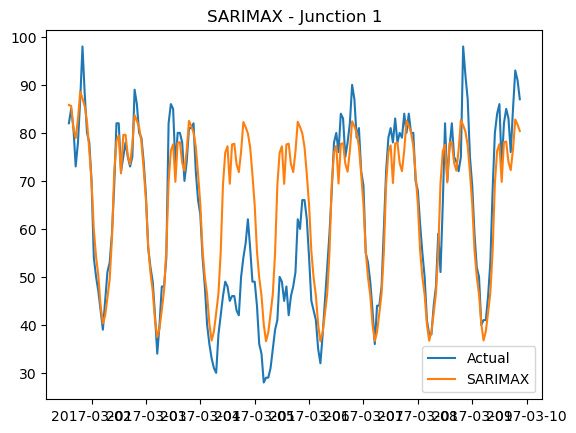

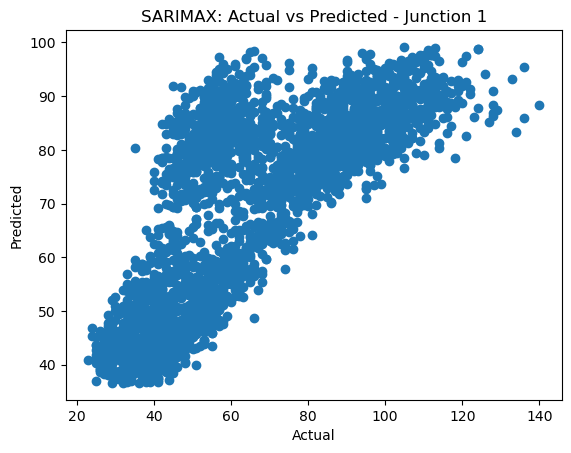

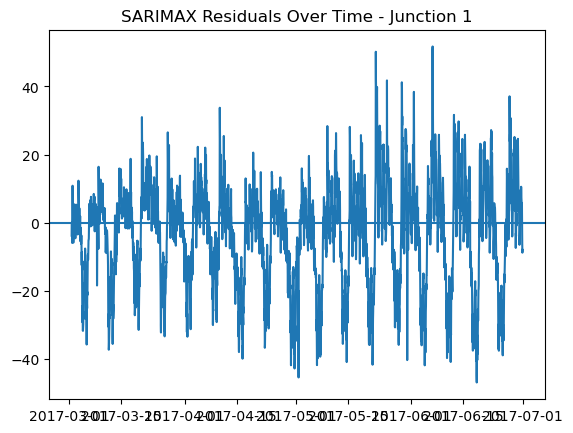

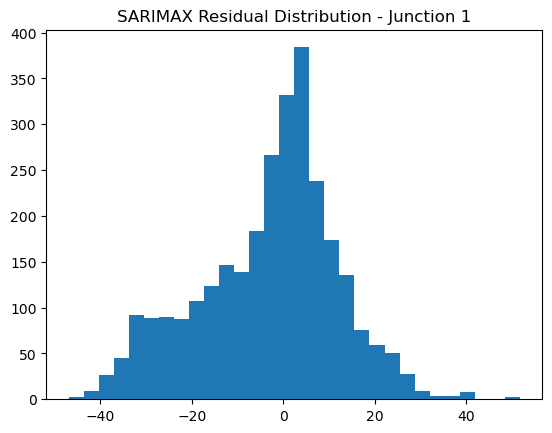


========== Junction 2 ==========
MAE: 6.416888908298203
RMSE: 7.934789123832147
R2: 0.0756115567009118


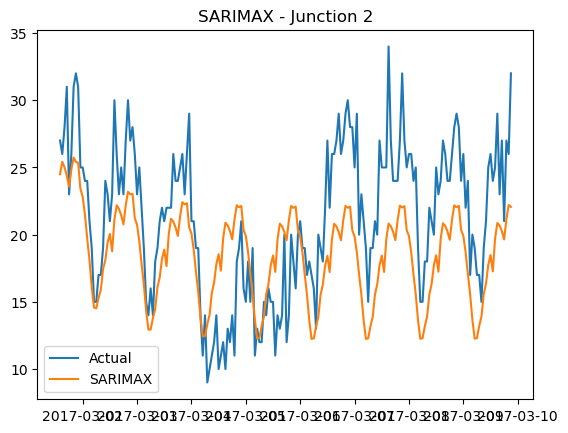

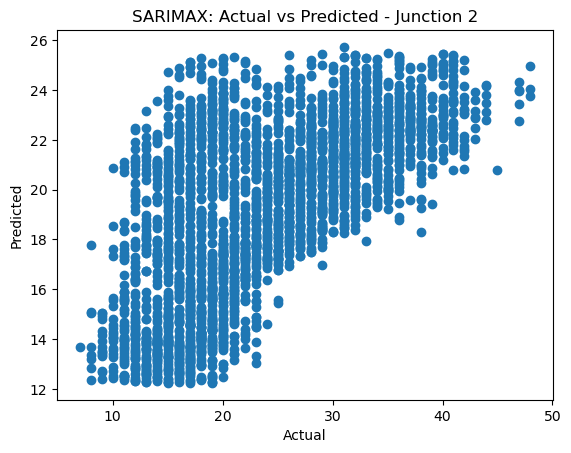

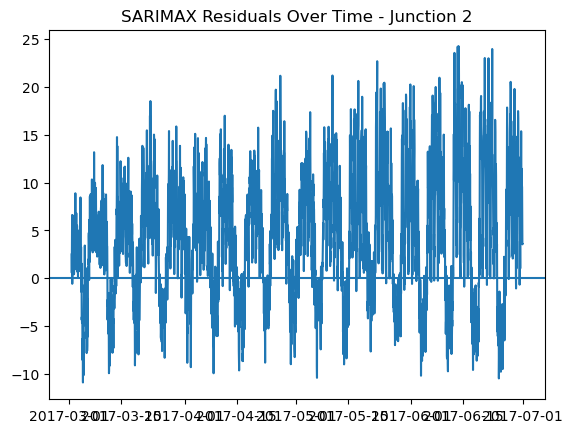

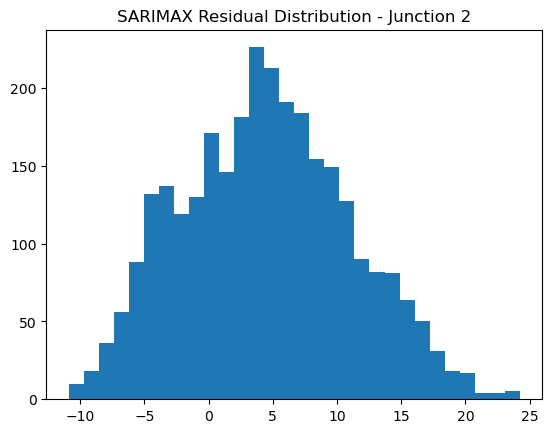


========== Junction 3 ==========
MAE: 5.772378599293515
RMSE: 8.751050415446388
R2: 0.2969539279208955


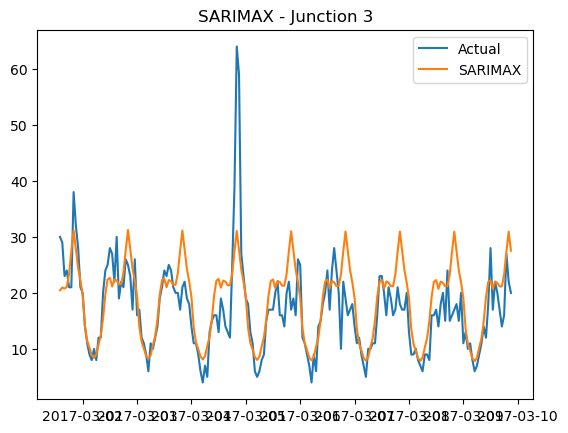

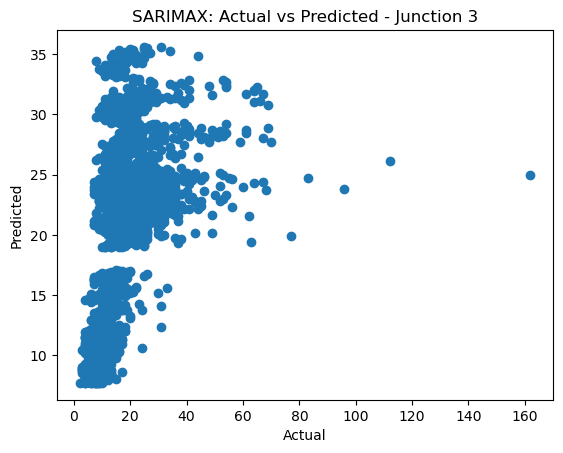

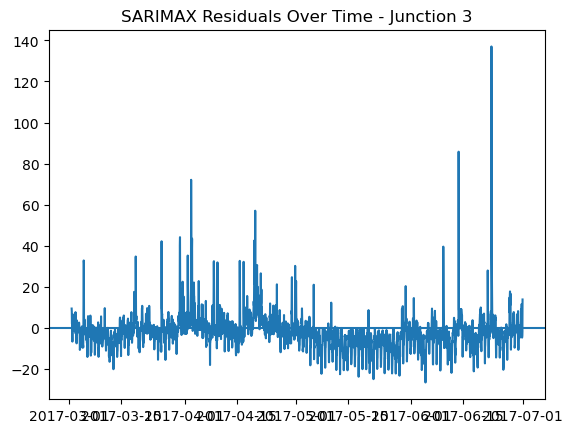

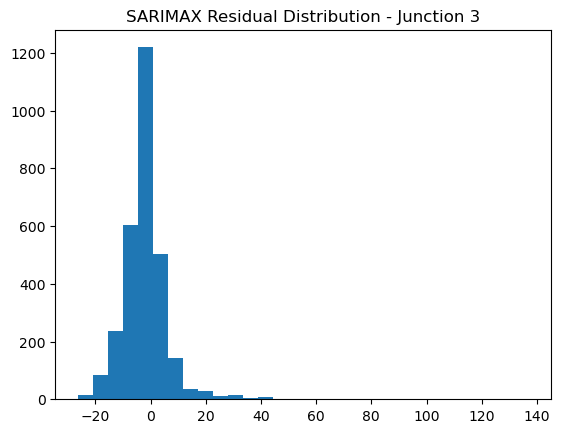


========== Junction 4 ==========
MAE: 2.9595863807409066
RMSE: 4.336235104275393
R2: -0.04122027410009643


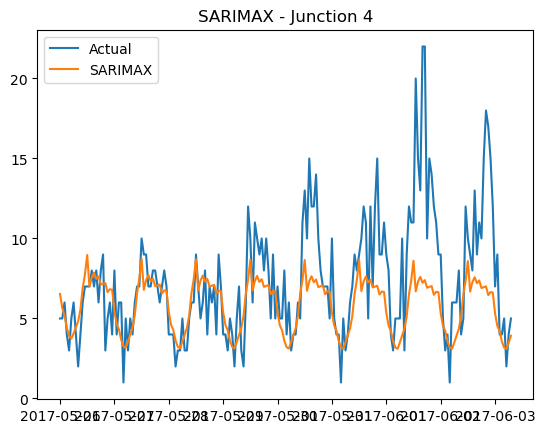

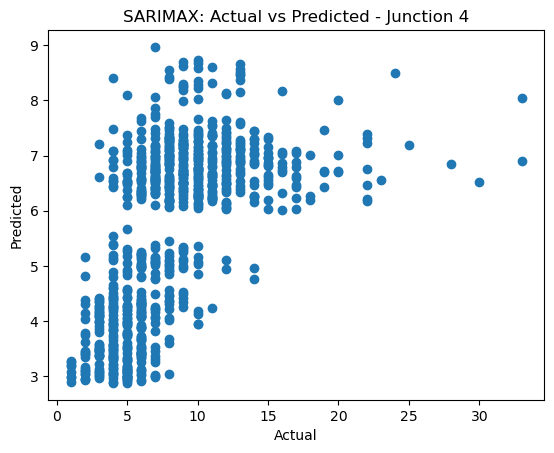

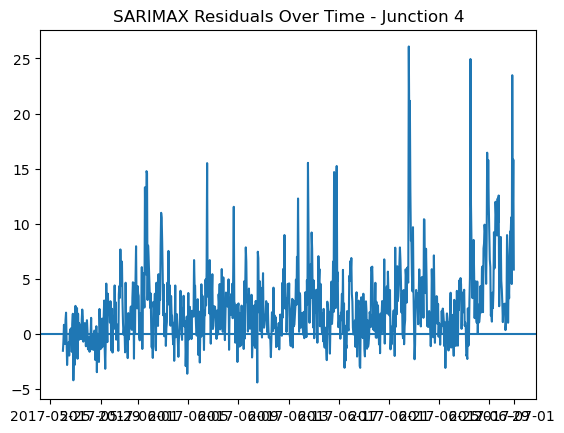

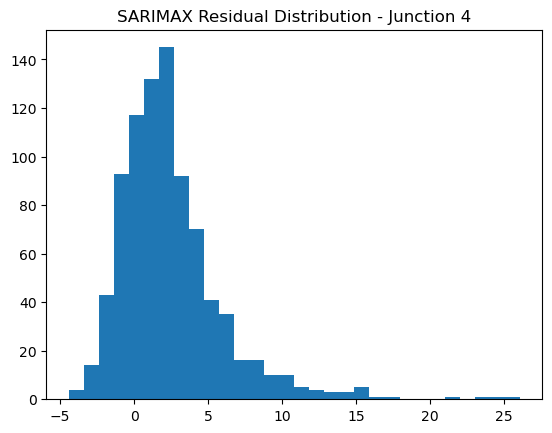


SARIMAX Summary:
   Junction        MAE       RMSE        R2
0         1  11.832207  15.512809  0.569001
1         2   6.416889   7.934789  0.075612
2         3   5.772379   8.751050  0.296954
3         4   2.959586   4.336235 -0.041220


In [119]:
#SARIMAX Model for each junction

junctions = df_model['Junction'].unique()

sarimax_results = []

for j in junctions:
    
    print(f"\n========== Junction {j} ==========")
    
    df_j = df_model[df_model['Junction'] == j].copy()
    df_j = df_j.sort_values('DateTime')
    df_j.set_index('DateTime', inplace=True)
    
    ts = df_j['Vehicles']
    
    # Time-based split (80% train, 20% test)
    split_index = int(len(ts) * 0.8)
    train = ts.iloc[:split_index]
    test = ts.iloc[split_index:]
    
    # SARIMAX model
    model = SARIMAX(
        train,
        order=(2,0,2),
        seasonal_order=(1,0,1,24),  # 24-hour seasonality
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    results = model.fit(disp=False)
    
    forecast = results.predict(
        start=test.index[0],
        end=test.index[-1]
    )
    
    # Evaluation
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    r2 = r2_score(test, forecast)
    
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    
    sarimax_results.append({
        'Junction': j,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    
    # Plot
    plt.figure()
    plt.plot(test.index[:200], test[:200], label="Actual")
    plt.plot(test.index[:200], forecast[:200], label="SARIMAX")
    plt.title(f"SARIMAX - Junction {j}")
    plt.legend()
    plt.show()

    residuals = test - forecast

    #Prediction vs Actual
    plt.figure()
    plt.scatter(test, forecast)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"SARIMAX: Actual vs Predicted - Junction {j}")
    plt.show()
    
    #Residuals over time
    plt.figure()
    plt.plot(test.index, residuals)
    plt.axhline(0)
    plt.title(f"SARIMAX Residuals Over Time - Junction {j}")
    plt.show()
    
    #Error distribution
    plt.figure()
    plt.hist(residuals, bins=30)
    plt.title(f"SARIMAX Residual Distribution - Junction {j}")
    plt.show()

sarimax_results_df = pd.DataFrame(sarimax_results)
print("\nSARIMAX Summary:")
print(sarimax_results_df)


========== Junction 1 ==========
MAE: 4.819921956167427
RMSE: 6.97883997629357
R2: 0.9127708720761951


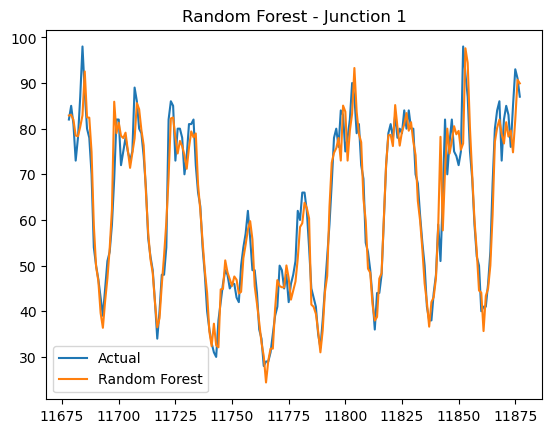

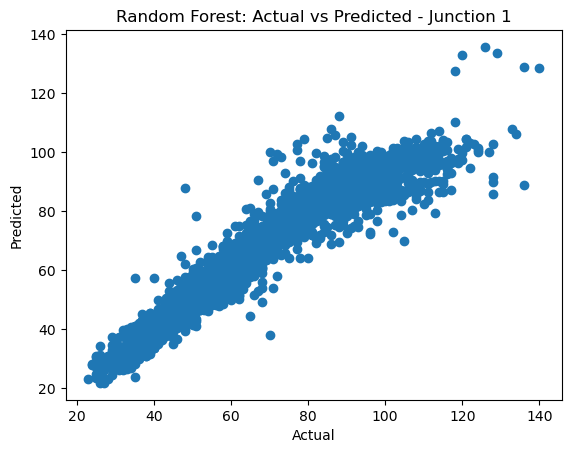

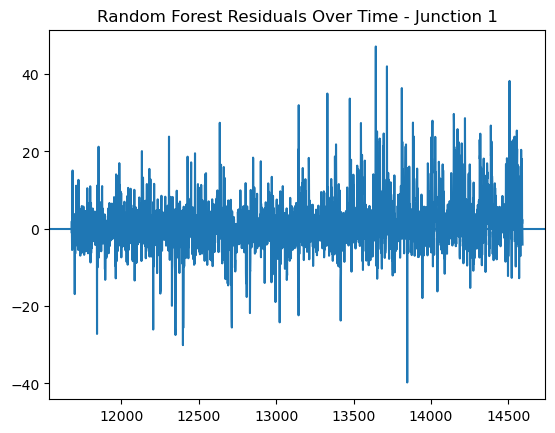

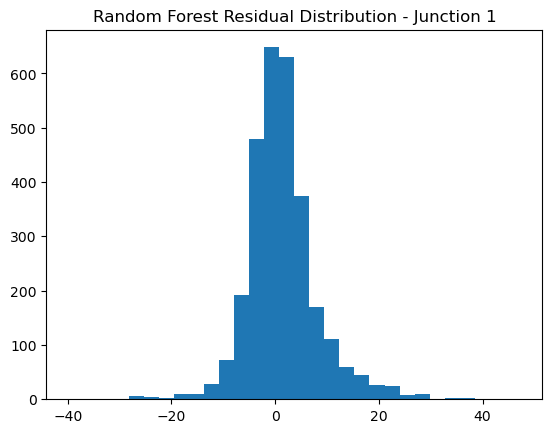


========== Junction 2 ==========
MAE: 3.674807523054486
RMSE: 4.949164102045993
R2: 0.6403770188042008


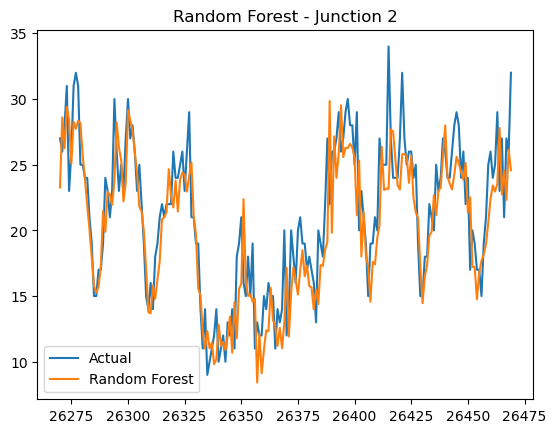

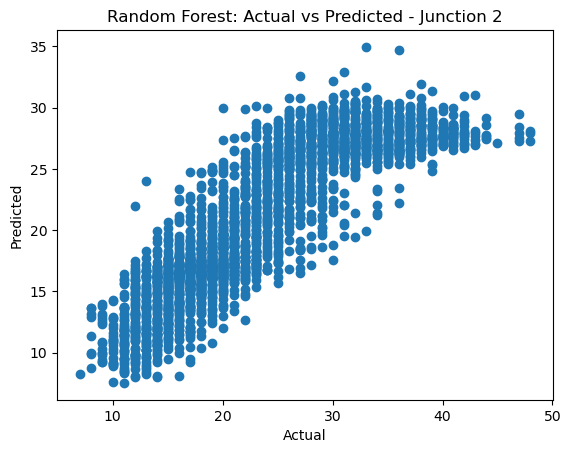

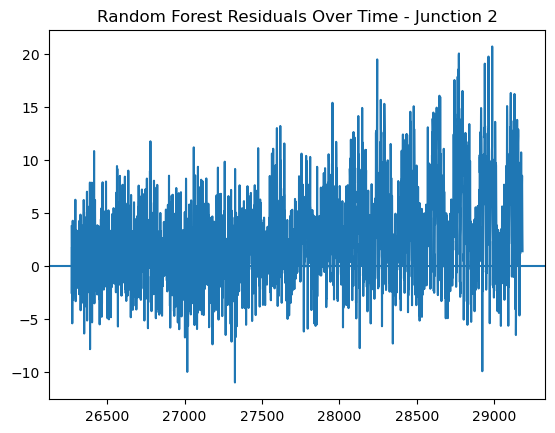

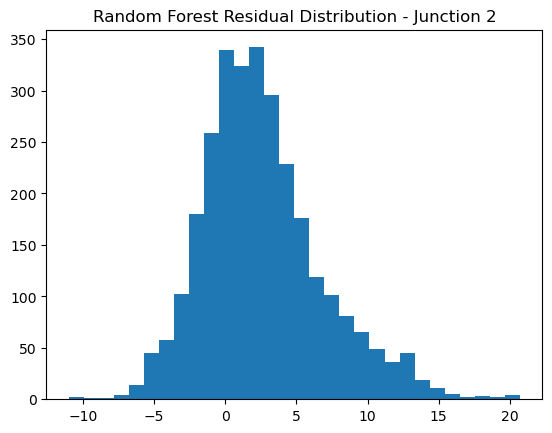


========== Junction 3 ==========
MAE: 3.1845898891310096
RMSE: 5.91421605853835
R2: 0.6788870748242771


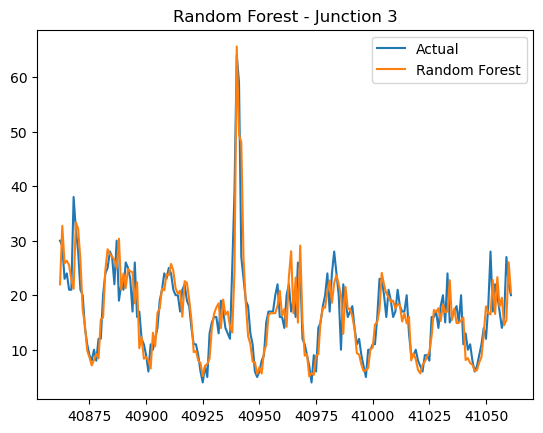

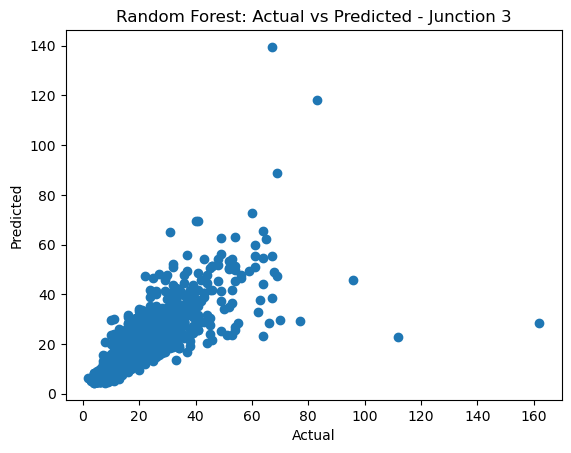

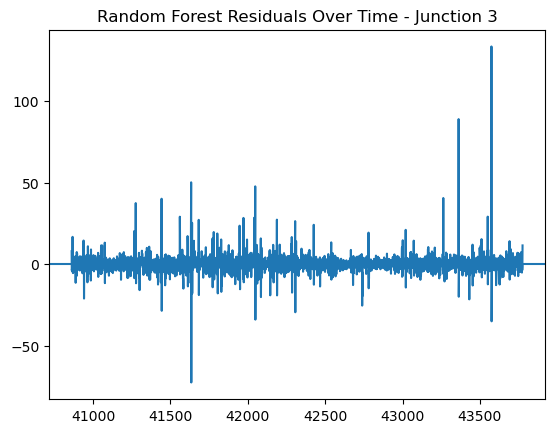

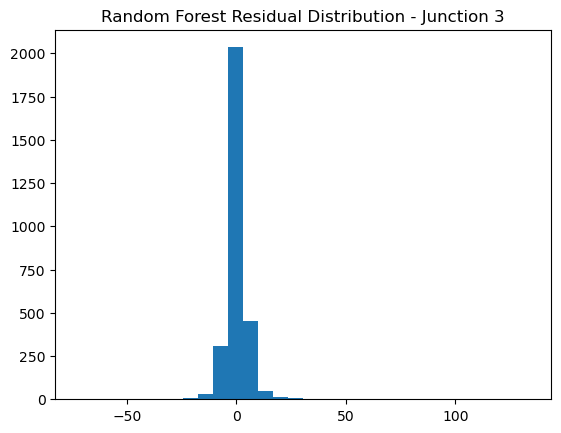


========== Junction 4 ==========
MAE: 2.2111373651782626
RMSE: 3.2679523857196178
R2: 0.4086175742647924


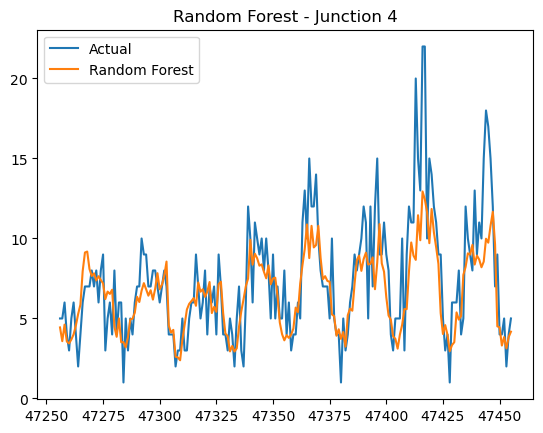

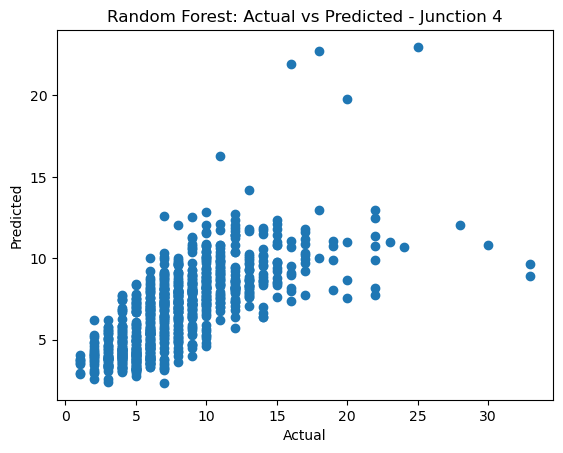

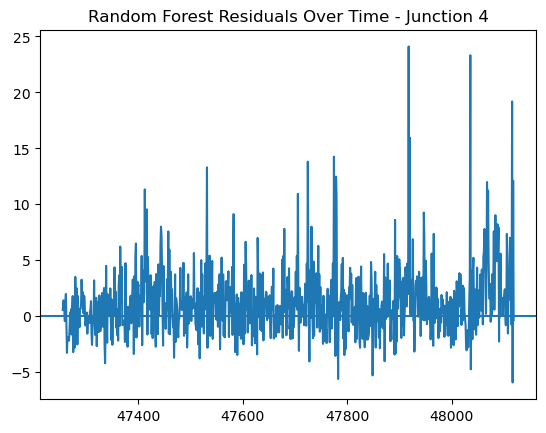

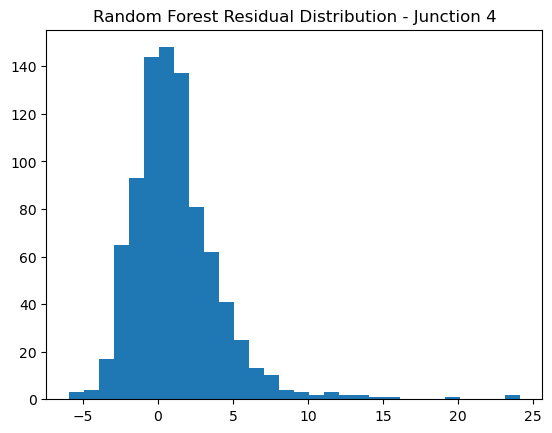


Random Forest Summary:
   Junction       MAE      RMSE        R2
0         1  4.819922  6.978840  0.912771
1         2  3.674808  4.949164  0.640377
2         3  3.184590  5.914216  0.678887
3         4  2.211137  3.267952  0.408618


In [120]:
#Random Forest Model for each junction

rf_results = []

feature_cols = [
    'Temperature', 'Precipitation', 'Humidity', 'WindSpeed',
    'Event_Flag', 'Weekend_Flag', 'Rain_Flag',
    'Hour', 'Weekday', 'Month',
    'Vehicles_lag1', 'Vehicles_lag3', 'Vehicles_lag24'
]

for j in junctions:
    
    print(f"\n========== Junction {j} ==========")
    
    df_j = df_model[df_model['Junction'] == j].copy()
    df_j = df_j.sort_values('DateTime')
    
    # Time-based split
    split_index = int(len(df_j) * 0.8)
    train = df_j.iloc[:split_index]
    test = df_j.iloc[split_index:]
    
    X_train = train[feature_cols]
    y_train = train['Vehicles']
    
    X_test = test[feature_cols]
    y_test = test['Vehicles']
    
    # Random Forest model
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    
    # Evaluation
    mae = mean_absolute_error(y_test, rf_pred)
    rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    r2 = r2_score(y_test, rf_pred)
    
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    
    rf_results.append({
        'Junction': j,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    
    # Plot
    plt.figure()
    plt.plot(y_test.index[:200], y_test[:200], label="Actual")
    plt.plot(y_test.index[:200], rf_pred[:200], label="Random Forest")
    plt.title(f"Random Forest - Junction {j}")
    plt.legend()
    plt.show()

    # Residuals
    residuals = y_test - rf_pred
    
    # 1️⃣ Prediction vs Actual
    plt.figure()
    plt.scatter(y_test, rf_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Random Forest: Actual vs Predicted - Junction {j}")
    plt.show()
    
    # 2️⃣ Residuals over time
    plt.figure()
    plt.plot(y_test.index, residuals)
    plt.axhline(0)
    plt.title(f"Random Forest Residuals Over Time - Junction {j}")
    plt.show()
    
    # 3️⃣ Error distribution
    plt.figure()
    plt.hist(residuals, bins=30)
    plt.title(f"Random Forest Residual Distribution - Junction {j}")
    plt.show()

rf_results_df = pd.DataFrame(rf_results)
print("\nRandom Forest Summary:")
print(rf_results_df)

In [121]:
#Comparing performances of both models

comparison = sarimax_results_df.merge(
    rf_results_df,
    on='Junction',
    suffixes=('_SARIMAX', '_RF')
)

print("\nModel Comparison:")
print(comparison)


Model Comparison:
   Junction  MAE_SARIMAX  RMSE_SARIMAX  R2_SARIMAX    MAE_RF   RMSE_RF  \
0         1    11.832207     15.512809    0.569001  4.819922  6.978840   
1         2     6.416889      7.934789    0.075612  3.674808  4.949164   
2         3     5.772379      8.751050    0.296954  3.184590  5.914216   
3         4     2.959586      4.336235   -0.041220  2.211137  3.267952   

      R2_RF  
0  0.912771  
1  0.640377  
2  0.678887  
3  0.408618  


In [122]:
#time-based cross-validation for Random Forest Model

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(n_splits=5)

rf_cv_results = []

for j in junctions:
    
    print(f"\n========== RF CV - Junction {j} ==========")
    
    df_j = df_model[df_model['Junction'] == j].copy()
    df_j = df_j.sort_values('DateTime')
    
    X = df_j[feature_cols]
    y = df_j['Vehicles']
    
    fold = 1
    mae_list, rmse_list, r2_list = [], [], []
    
    for train_index, test_index in tscv.split(X):
        
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )
        
        rf.fit(X_train, y_train)
        pred = rf.predict(X_test)
        
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        
        mae_list.append(mae)
        rmse_list.append(rmse)
        r2_list.append(r2)
        
        print(f"Fold {fold} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")
        fold += 1
    
    print("Average Performance:")
    print("MAE:", np.mean(mae_list))
    print("RMSE:", np.mean(rmse_list))
    print("R2:", np.mean(r2_list))
    
    rf_cv_results.append({
        'Junction': j,
        'MAE_mean': np.mean(mae_list),
        'RMSE_mean': np.mean(rmse_list),
        'R2_mean': np.mean(r2_list)
    })

rf_cv_df = pd.DataFrame(rf_cv_results)
print("\nRandom Forest Cross-Validation Summary:")
print(rf_cv_df)


========== RF CV - Junction 1 ==========
Fold 1 → MAE: 3.46, RMSE: 4.74, R2: 0.80
Fold 2 → MAE: 3.66, RMSE: 5.13, R2: 0.88
Fold 3 → MAE: 4.90, RMSE: 6.73, R2: 0.84
Fold 4 → MAE: 4.40, RMSE: 6.73, R2: 0.89
Fold 5 → MAE: 4.72, RMSE: 6.92, R2: 0.92
Average Performance:
MAE: 4.22862768474552
RMSE: 6.049573696980228
R2: 0.8649073005846262

========== RF CV - Junction 2 ==========
Fold 1 → MAE: 1.87, RMSE: 2.37, R2: 0.54
Fold 2 → MAE: 1.91, RMSE: 2.45, R2: 0.68
Fold 3 → MAE: 3.09, RMSE: 4.00, R2: 0.16
Fold 4 → MAE: 3.70, RMSE: 4.81, R2: 0.40
Fold 5 → MAE: 3.17, RMSE: 4.18, R2: 0.76
Average Performance:
MAE: 2.749728086292987
RMSE: 3.559931520969461
R2: 0.5090629863283412

========== RF CV - Junction 3 ==========
Fold 1 → MAE: 3.12, RMSE: 4.97, R2: 0.72
Fold 2 → MAE: 2.70, RMSE: 5.83, R2: 0.67
Fold 3 → MAE: 3.05, RMSE: 5.21, R2: 0.71
Fold 4 → MAE: 3.33, RMSE: 6.60, R2: 0.68
Fold 5 → MAE: 3.21, RMSE: 6.16, R2: 0.68
Average Performance:
MAE: 3.0821144340485676
RMSE: 5.754072610789581
R2: 0.691